# Análise Socioeconômica e Desempenho no ENEM 2020

Este notebook apresenta a exploração inicial dos microdados do ENEM 2020.

O objetivo é compreender a estrutura dos dados, identificar as variáveis importantes e preparar a base para as análises socioeconômicas.

## Perguntas de Pesquisa

Neste projeto, buscamos responder às seguintes questões sobre o desempenho no ENEM 2020:

1. **Correlação entre Renda e Ausência**: A taxa de ausência é maior entre os participantes de faixas de renda mais baixas?
2. **O Teto de Desempenho**: Candidatos de faixas de renda mais altas apresentam, consistentemente, maiores notas em Matemática e Ciências da Natureza?
3. **A Redação como Equalizador**: A disparidade de notas entre as faixas de renda é menor na redação do que em áreas de exatas?
4. **Escada da Renda**: Existe um patamar de renda onde o ganho de nota começa a estagnar (retornos marginais decrescentes)?

## Dicionário de Variáveis

Para melhor compreensão da análise, realizamos a tradução das variáveis codificadas presentes no dataset para termos de fácil interpretação.

| Variável | Descrição | Tipo |
| :--- | :--- | :--- |
| **Q006** | Renda mensal familiar declarada | Categórica |
| **TP_PRESENCA_CN** | Presença na prova de Ciências da Natureza | Numérico |
| **TP_PRESENCA_CH** | Presença na prova de Ciências da Humanas | Numérico |
| **TP_PRESENCA_LC** | Presença na prova de Ciências da Linguagens e Códigos | Numérico 
| **TP_PRESENCA_MT** | Presença na prova de Ciências da Matemática | Numérico |
| **NU_NOTA_CN** | Nota da prova de Ciências da Natureza | Numérico |
| **NU_NOTA_CH** | Nota da prova de Ciências Humanas | Numérico |
| **NU_NOTA_LC** | Nota da prova de Linguagens e Códigos | Numérico |
| **NU_NOTA_MT** | Nota da prova de Matemática | Numérico |
| **NU_NOTA_REDACAO** | Nota da prova de Redação | Numérico |

**Observação:** Os valores para as variáveis de presença (`TP_PRESENCA_`) seguem a codificação:
* **0**: Faltou à prova.
* **1**: Compareceu à prova.
* **2**: Foi eliminado da prova.

## Importação das bibliotecas

Nesta etapa serão importadas as bibliotecas utilizadas para manipulação e análise dos dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carregamento dos dados

O arquivo utilizado contém os microdados dos participantes do ENEM 2020.

In [2]:
colunas_selecionadas = ['Q006', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', "TP_PRESENCA_CN", "TP_PRESENCA_CH", "TP_PRESENCA_LC", "TP_PRESENCA_MT"]

df = pd.read_csv(
    "../dados/brutos/microdados_enem_2020/DADOS/MICRODADOS_ENEM_2020.csv",
    encoding="latin-1",
    sep=";",
    usecols=colunas_selecionadas
)

In [3]:
display(df)

,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006
0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,1,1,604.1,661.7,595.3,711.3,580.0,NaN
2,0,0,0,0,NaN,NaN,NaN,NaN,NaN,B
3,1,1,1,1,620.8,675.0,624.2,759.4,760.0,NaN
4,0,0,0,0,NaN,NaN,NaN,NaN,NaN,B
...,...,...,...,...,...,...,...,...,...,...
5783104,1,1,1,1,508.3,661.4,658.3,725.7,900.0,G
5783105,1,1,1,1,570.5,646.1,607.2,719.5,660.0,NaN
5783106,1,1,1,1,418.8,597.5,674.5,648.1,660.0,NaN
5783107,0,0,0,0,NaN,NaN,NaN,NaN,NaN,N


## Visão inicial dos dados

Primeiramente vamos verificar o tamanho da base e algumas informações gerais. Analisaremos a quantidade de dados ausentes (NaN) em cada coluna, pois eles representam os participantes que não realizaram alguma das provas ou foram eliminados.

In [4]:
df.isnull().sum()

TP_PRESENCA_CN           0
TP_PRESENCA_CH           0
TP_PRESENCA_LC           0
TP_PRESENCA_MT           0
NU_NOTA_CN         3185669
NU_NOTA_CH         3028969
NU_NOTA_LC         3028969
NU_NOTA_MT         3185669
NU_NOTA_REDACAO    3028969
Q006                 95966
dtype: int64

Para garantir a qualidade da análise, removeremos as linhas que não possuem a informação de renda (Q006).

In [5]:
df_limpo = df.dropna(subset=["Q006"])

display(df_limpo)

,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006
2,0,0,0,0,NaN,NaN,NaN,NaN,NaN,B
4,0,0,0,0,NaN,NaN,NaN,NaN,NaN,B
5,1,1,1,1,498.1,604.7,505.4,526.7,700.0,C
8,1,1,1,1,439.7,383.5,486.2,448.5,600.0,B
9,0,0,0,0,NaN,NaN,NaN,NaN,NaN,B
...,...,...,...,...,...,...,...,...,...,...
5783101,1,1,1,1,393.8,401.2,467.4,340.0,500.0,C
5783102,0,0,0,0,NaN,NaN,NaN,NaN,NaN,C
5783104,1,1,1,1,508.3,661.4,658.3,725.7,900.0,G
5783107,0,0,0,0,NaN,NaN,NaN,NaN,NaN,N


Verificando se ainda existe valores NaN no novo dataset limpo.

In [6]:
df_limpo.isnull().sum()

TP_PRESENCA_CN           0
TP_PRESENCA_CH           0
TP_PRESENCA_LC           0
TP_PRESENCA_MT           0
NU_NOTA_CN         3117256
NU_NOTA_CH         2963254
NU_NOTA_LC         2963254
NU_NOTA_MT         3117256
NU_NOTA_REDACAO    2963254
Q006                     0
dtype: int64

Já nas outras colunas, decidimos manter os valores ausentes (*NaN*) para preservar a representatividade real da população inscrita, evitando o viés de seleção que ocorreria ao excluir participantes que não completaram as provas. Essa estratégia será devidamente justificada no relatório final do projeto, destacando a complexidade do acesso e da conclusão do exame.

## Pergunta 1: A taxa de ausência é maior entre os participantes de faixas de renda mais baixas?

Criação de duas colunas novas, **Ausente_Dia_01** para dizer que o participante faltou no primeiro dia de prova, ou seja, em ciências humanas e redação, e **Ausente_Dia_02** para dizer que faltou no segundo dia, ou seja, em ciências exatas.

In [7]:
# Para o dia de Ciências Humanas

df_limpo["Ausente_Dia_01"] = ((df_limpo["TP_PRESENCA_CH"] == 0) & (df_limpo["TP_PRESENCA_LC"] == 0)).astype(int)

# Para o dia de Ciências Exatas

df_limpo["Ausente_Dia_02"] = ((df_limpo["TP_PRESENCA_CN"] == 0) & (df_limpo["TP_PRESENCA_MT"] == 0)).astype(int)


display(df_limpo)

,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006,Ausente_Dia_01,Ausente_Dia_02
2,0,0,0,0,NaN,NaN,NaN,NaN,NaN,B,1,1
4,0,0,0,0,NaN,NaN,NaN,NaN,NaN,B,1,1
5,1,1,1,1,498.1,604.7,505.4,526.7,700.0,C,0,0
8,1,1,1,1,439.7,383.5,486.2,448.5,600.0,B,0,0
9,0,0,0,0,NaN,NaN,NaN,NaN,NaN,B,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5783101,1,1,1,1,393.8,401.2,467.4,340.0,500.0,C,0,0
5783102,0,0,0,0,NaN,NaN,NaN,NaN,NaN,C,1,1
5783104,1,1,1,1,508.3,661.4,658.3,725.7,900.0,G,0,0
5783107,0,0,0,0,NaN,NaN,NaN,NaN,NaN,N,1,1


Verificando a quantidade, em porcentagem, de participantes por cada faixa de renda esteve ou não presente em cada um dos dias.

In [8]:
df_por_renda = df_limpo.groupby("Q006")[['Ausente_Dia_01', 'Ausente_Dia_02']].mean()

display(df_por_renda)

,Ausente_Dia_01,Ausente_Dia_02
Q006,,
A,0.597118,0.626320
B,0.566811,0.595757
C,0.564452,0.592709
D,0.536625,0.563750
E,0.493373,0.519980
F,0.459366,0.485123
G,0.405353,0.430715
H,0.365436,0.389724
I,0.330098,0.354445


Plotando um gráfico para melhor visualização

[]

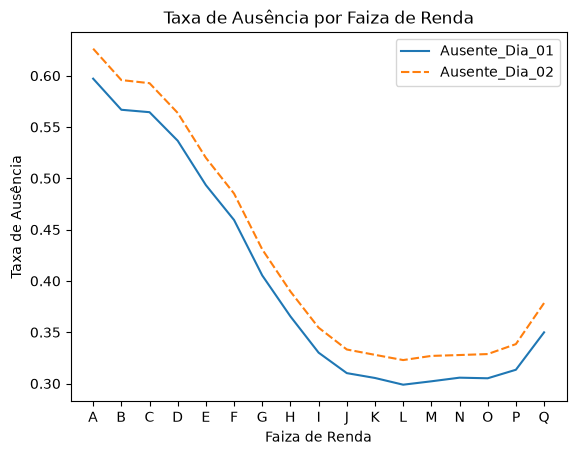

In [9]:
sns.lineplot(data = df_por_renda)

plt.title("Taxa de Ausência por Faiza de Renda")
plt.xlabel("Faiza de Renda")
plt.ylabel("Taxa de Ausência")
plt.plot()

### Legenda: Faixas de Renda Mensal (Q006)

| Letra | Renda Mensal |
| :--- | :--- |
| **A** | Nenhuma renda |
| **B** | Até 1 salário mínimo |
| **C** | De 1 até 1,5 salário mínimo |
| **D** | De 1,5 até 2 salários mínimos |
| **E** | De 2 até 2,5 salários mínimos |
| **F** | De 2,5 até 3 salários mínimos |
| **G** | De 3 até 4 salários mínimos |
| **H** | De 4 até 5 salários mínimos |
| **I** | De 5 até 6 salários mínimos |
| **J** | De 6 até 7 salários mínimos |
| **K** | De 7 até 8 salários mínimos |
| **L** | De 8 até 9 salários mínimos |
| **M** | De 9 até 10 salários mínimos |
| **N** | De 10 até 12 salários mínimos |
| **O** | De 12 até 15 salários mínimos |
| **P** | De 15 até 20 salários mínimos |
| **Q** | Acima de 20 salários mínimos |

## Uma análise do gráfico

Os dados revelam uma correlação negativa clara entre a renda familiar e a taxa de ausência dos participantes. Observa-se que, nas faixas de renda mais baixas (Classes A e B), a taxa de ausência chega a atingir cerca de 60%, indicando uma barreira significativa de acesso e permanência no exame para os grupos mais vulneráveis socioeconomicamente.

À medida que a renda aumenta, observa-se uma tendência consistente de queda na evasão, que estabiliza em torno de 30% nas faixas de renda mais elevadas (Classes L a Q). Esse padrão sugere que fatores como custo de transporte, necessidade de trabalhar nos dias de prova e falta de rede de apoio impactam desproporcionalmente os candidatos de menor renda, impedindo a conclusão das duas etapas do exame.

Além disso, nota-se que a curva de ausência no Dia 02 (Ciências da Natureza e Matemática) apresenta-se sistematicamente acima da curva do Dia 01 (Linguagens e Ciências Humanas) em todas as faixas de renda. Isso levanta um ponto de atenção importante: a evasão não ocorre apenas antes da prova, mas se agrava após o primeiro dia, sugerindo um desgaste ou desestímulo específico em relação às áreas de exatas.